> **LEGACY RUN (Task 4) — DO NOT CITE adaptive FPR results.**
>
> This notebook is the pre-fix drift-aware execution. Fixed-threshold stream FPR was ~97% due to a score/threshold invert mismatch.
> Thesis evidence must come from `mdc_drift_aware_output_v2.ipynb` after Tasks 1-3 gates PASS.
> See `notebook/run/README_RUNS.md` and `docs/claim_evidence_matrix.md`.


# MDC vNext — Drift-Aware System + Baselines + Thesis Figures

**Prerequisites (already on Drive):**
- `Module4_MDC/runs/vnext_run/` — checkpoint, scores, metrics (8/8 PASS)
- `Module4_MDC/processed_vnext/` — windows + drift baseline (or gdown fallback below)
- `mdc_eval_utils.py` — optional separate upload; **§3b auto-bootstraps** embedded copy if missing

**Implements (WBS Phase C–E):**
1. Adaptive threshold in **alert space** (fixes inverted-score artifact) + F1/recall comparison
2. Incremental fine-tune on drift slice (§3.3) — report honest negative if AUC drops
3. **Simulated** streaming replay (timestamp order when available, else container lexsort)
4. Isolation Forest baseline — benign-only, mean+max pooling, auto contamination
5. Ablation comparison table (§4.4) + optional retrain ablations from model notebook
6. Bootstrap CI + TPR@FPR + latency (§5.2)
7. Thesis figure export @ 300 dpi

**Does NOT retrain from scratch** — loads `checkpoint_vnext.pt` (default model matching `scores_vnext.npz`).

## 0. Environment

In [15]:
import sys, subprocess
from pathlib import Path
try:
    import google.colab
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False
if _IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'torch', 'scikit-learn', 'matplotlib', 'gdown'], check=False)
    # Ensure eval utils on path (upload mdc_eval_utils.py to /content/ or clone repo)
    for _p in [Path('/content/mdc_eval_utils.py'), Path('/content/notebook/mdc_eval_utils.py')]:
        if _p.is_file() and str(_p.parent) not in sys.path:
            sys.path.insert(0, str(_p.parent))
print(f'In Colab: {_IN_COLAB}')

In Colab: True


## 1. Configuration

In [16]:
from __future__ import annotations
import os, json, gc, math, time, shutil
from pathlib import Path
from datetime import datetime, timezone
import numpy as np

VERSION = 'vnext'
SEED = 42
np.random.seed(SEED)

# --- Drift-aware hyperparams (WBS §2.1–2.3) ---
ADAPTIVE_ALPHA        = 2.5
BENIGN_BUFFER_SIZE    = 100
THRESHOLD_UPDATE_EVERY= 20
PSI_CHECK_EVERY       = 100
PSI_TRIGGER           = 0.10      # mean PSI across features
DRIFT_SLICE_FRAC      = 0.30        # last 30% of stream = drift period
STABLE_SLICE_FRAC     = 0.70
FINETUNE_STEPS        = 50
FINETUNE_LR           = 1e-5
FINETUNE_BENIGN_N     = 200
RUN_ALPHA_SWEEP       = True        # sensitivity analysis for thesis
ALPHA_SWEEP_VALUES    = (1.5, 2.0, 2.5, 3.0)

# --- Scoring (match model vNext) ---
SCORE_MEAN_W = 0.3
SCORE_MAX_W  = 0.7
SCORE_BATCH_SIZE = 128
BATCH_SIZE = 32

DRIVE_PROCESSED_FOLDER_ID = '1aFaour_PvyIVfy8l11T0QMCtC4-U8NQ9'
LOCAL_DATA_CACHE = Path('/content/processed_vnext')
LOCAL_RUN_CACHE  = Path('/content/vnext_run_local')
BUNDLE_RUN_DIR   = Path('/content/_bundle_restore/model_runs')

if _IN_COLAB:
    DRIVE_RUN_DIR  = Path('/content/drive/MyDrive/Module4_MDC/runs/vnext_run')
    DRIVE_DATA_DIR = Path('/content/drive/MyDrive/Module4_MDC/processed_vnext')
    RUN_DIR  = LOCAL_RUN_CACHE          # always load from local cache (FUSE-safe)
    DATA_DIR = DRIVE_DATA_DIR           # resolved in §2
    OUT_DIR  = LOCAL_RUN_CACHE / 'drift_aware'
    DRIVE_OUT_DIR = DRIVE_RUN_DIR / 'drift_aware'
else:
    DRIVE_RUN_DIR  = Path('../outputs/mdc_vnext_run')
    DRIVE_DATA_DIR = Path('../data/processed')
    RUN_DIR  = DRIVE_RUN_DIR
    DATA_DIR = DRIVE_DATA_DIR
    OUT_DIR  = RUN_DIR / 'drift_aware'
    DRIVE_OUT_DIR = OUT_DIR

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUT_DIR / 'thesis_figures_300dpi'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Config loaded')
print(f'  DRIVE_RUN_DIR  : {DRIVE_RUN_DIR}')
print(f'  RUN_DIR (load) : {RUN_DIR}')
print(f'  DATA_DIR       : {DATA_DIR}')
print(f'  OUT_DIR        : {OUT_DIR}')

Config loaded
  DRIVE_RUN_DIR  : /content/drive/MyDrive/Module4_MDC/runs/vnext_run
  RUN_DIR (load) : /content/vnext_run_local
  DATA_DIR       : /content/drive/MyDrive/Module4_MDC/processed_vnext
  OUT_DIR        : /content/vnext_run_local/drift_aware


## 2. Mount Drive + load artifacts
Skips remount if already mounted. Falls back to gdown when `processed_vnext` missing on Drive.

In [17]:
if _IN_COLAB:
    mydrive = Path('/content/drive/MyDrive')
    if not mydrive.is_dir():
        from google.colab import drive
        drive.mount('/content/drive')
    else:
        print('Drive already mounted — skipping drive.mount()')

NPZ_FILE   = f'windows_{VERSION}.npz'
DRIFT_FILE = f'drift_baseline_{VERSION}.npz'
RUN_ARTIFACTS = [
    'checkpoint_vnext.pt', 'scores_vnext.npz', 'metrics_vnext.json',
    'drift_report_vnext.npz', 'eval_vnext.png',
    'eval_per_attack_type.png', 'eval_per_attack_roc.png', 'eval_multiclass.json',
]

def _download_processed_folder(folder_id, cache_dir):
    import gdown
    cache_dir.mkdir(parents=True, exist_ok=True)
    print(f'Downloading Drive folder {folder_id} -> {cache_dir} ...')
    gdown.download_folder(id=folder_id, output=str(cache_dir), quiet=False)
    return cache_dir

def _first_existing_file(name, roots):
    for root in roots:
        if root is None:
            continue
        root = Path(root)
        p = root / name
        try:
            if p.is_file():
                return p
        except OSError:
            pass
    return None

def _resolve_data_dir():
    global DATA_DIR, DRIFT_PATH, NPZ_PATH
    roots = [DRIVE_DATA_DIR, LOCAL_DATA_CACHE]
    hit = _first_existing_file(NPZ_FILE, roots)
    if hit is not None:
        DATA_DIR = hit.parent
        NPZ_PATH = hit
        DRIFT_PATH = DATA_DIR / DRIFT_FILE
        print(f'Using DATA_DIR: {DATA_DIR}')
        return
    if DRIVE_PROCESSED_FOLDER_ID:
        cache = _download_processed_folder(DRIVE_PROCESSED_FOLDER_ID, LOCAL_DATA_CACHE)
        DATA_DIR = cache
        NPZ_PATH = DATA_DIR / NPZ_FILE
        DRIFT_PATH = DATA_DIR / DRIFT_FILE
        print(f'Using gdown cache: {DATA_DIR}')
        return
    raise FileNotFoundError('processed_vnext not found — paste to Drive or set DRIVE_PROCESSED_FOLDER_ID')

def _resolve_run_dir():
    """Sync run artifacts to LOCAL_RUN_CACHE — Drive FUSE often lies about file visibility."""
    global RUN_DIR, CKPT_PATH, SCORES_PATH, METRICS_PATH
    LOCAL_RUN_CACHE.mkdir(parents=True, exist_ok=True)

    search_roots = [
        LOCAL_RUN_CACHE,
        DRIVE_RUN_DIR,
        BUNDLE_RUN_DIR,
        Path('/content/vnext_run'),
    ]
    if _IN_COLAB and mydrive.is_dir():
        try:
            for p in mydrive.rglob('checkpoint_vnext.pt'):
                search_roots.append(p.parent)
        except OSError:
            pass

    print('Searching run artifacts in:')
    for r in search_roots:
        print(f'  {r}  exists={Path(r).exists()}')

    copied, missing = [], []
    for name in RUN_ARTIFACTS:
        src = _first_existing_file(name, search_roots)
        dst = LOCAL_RUN_CACHE / name
        if src is not None:
            if (not dst.is_file()) or dst.stat().st_size != src.stat().st_size:
                shutil.copy2(src, dst)
            copied.append(f'{name} <- {src}')
        else:
            missing.append(name)

    print('\nSynced to local cache:')
    for line in copied:
        print(f'  OK {line}')
    if missing:
        print('  MISSING:', ', '.join(missing))

    RUN_DIR = LOCAL_RUN_CACHE
    CKPT_PATH = RUN_DIR / 'checkpoint_vnext.pt'
    SCORES_PATH = RUN_DIR / 'scores_vnext.npz'
    METRICS_PATH = RUN_DIR / 'metrics_vnext.json'

    required = [('checkpoint', CKPT_PATH), ('scores', SCORES_PATH), ('metrics', METRICS_PATH)]
    for label, p in required:
        if not p.is_file():
            raise FileNotFoundError(
                f'Missing {label}: {p}\n'
                'FUSE cannot see Drive files in this kernel.\n'
                'FIX: upload Module4_vNext_bundle.zip to /content/ and run:\n'
                '  !unzip -o /content/Module4_vNext_bundle.zip -d /content/_bundle_restore\n'
                'Then re-run this cell.')
        print(f'OK {label}: {p} ({p.stat().st_size:,} bytes)')

_resolve_data_dir()
_resolve_run_dir()

for p, label in [(NPZ_PATH, 'npz')]:
    if not p.is_file():
        raise FileNotFoundError(f'Missing {label}: {p}')
    print(f'OK {label}: {p.name} ({p.stat().st_size:,} bytes)')

z = np.load(NPZ_PATH, allow_pickle=True)
X_train = z['X_train'].astype(np.float32)
X_val   = z['X_val'].astype(np.float32)
X_test  = z['X_test'].astype(np.float32)
y_val   = z['y_val'].astype(np.int8)
y_test  = z['y_test'].astype(np.int8)
c_test  = z['c_test'] if 'c_test' in z.files else None
ts_test = z['ts_test'] if 'ts_test' in z.files else None
ts_val  = z['ts_val']  if 'ts_val'  in z.files else None
T, n_features = X_test.shape[1], X_test.shape[2]
z.close()

if ts_test is not None:
    print(f'ts_test available: unix range [{int(ts_test.min())}, {int(ts_test.max())}]')
else:
    print('ts_test not in npz — stream uses container lexsort (re-run preprocess for timestamps)')

scores_z = np.load(SCORES_PATH)
s_val  = scores_z['s_val']
s_test = scores_z['s_test']
scores_z.close()

metrics = json.loads(METRICS_PATH.read_text())
SCORE_INVERT = bool(metrics.get('auto_score_flip', True))
print(f'Loaded windows: train={X_train.shape} val={X_val.shape} test={X_test.shape}')
print(f'SCORE_INVERT={SCORE_INVERT}  (from metrics_vnext.json)')

drift_z = None
if DRIFT_PATH.is_file():
    drift_z = np.load(DRIFT_PATH, allow_pickle=True)
    print(f'Drift baseline: {drift_z["mean"].shape[0]} features')
else:
    print('WARN: drift_baseline missing — PSI trigger will use feature-mean proxy')

Drive already mounted — skipping drive.mount()
Using DATA_DIR: /content/drive/MyDrive/Module4_MDC/processed_vnext
Searching run artifacts in:
  /content/vnext_run_local  exists=True
  /content/drive/MyDrive/Module4_MDC/runs/vnext_run  exists=True
  /content/_bundle_restore/model_runs  exists=False
  /content/vnext_run  exists=False
  /content/drive/MyDrive/Module4_MDC/runs/vnext_run  exists=True

Synced to local cache:
  OK checkpoint_vnext.pt <- /content/vnext_run_local/checkpoint_vnext.pt
  OK scores_vnext.npz <- /content/vnext_run_local/scores_vnext.npz
  OK metrics_vnext.json <- /content/vnext_run_local/metrics_vnext.json
  OK drift_report_vnext.npz <- /content/vnext_run_local/drift_report_vnext.npz
  OK eval_vnext.png <- /content/vnext_run_local/eval_vnext.png
  OK eval_per_attack_type.png <- /content/vnext_run_local/eval_per_attack_type.png
  OK eval_per_attack_roc.png <- /content/vnext_run_local/eval_per_attack_roc.png
  OK eval_multiclass.json <- /content/vnext_run_local/eval_m

## 3. Model + scoring (load checkpoint, no retrain)

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, matthews_corrcoef,
    balanced_accuracy_score, confusion_matrix, roc_curve,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
feat_std = ckpt.get('feat_std')

# scores_vnext.npz was saved from the DEFAULT model (§8/§17), not HPO model_best.
# model_best uses different arch (dim_ff=192, bn=16, 3 enc layers) -> size mismatch if mis-loaded.
USE_HPO_MODEL = False

def _arch_from_config(cfg):
    d_model = cfg['d_model']
    return dict(
        d_model=d_model,
        nhead=cfg['nhead'],
        num_enc_layers=cfg['num_enc_layers'],
        num_dec_layers=cfg['num_dec_layers'],
        dim_ff=cfg['dim_ff'],
        dropout=cfg['dropout'],
        bottleneck_dim=cfg['bottleneck_dim'],
    )

def _arch_from_hpo(hp):
    d_model = hp['d_model']
    return dict(
        d_model=d_model,
        nhead=4 if d_model % 4 == 0 else 2,
        num_enc_layers=hp['num_enc_layers'],
        num_dec_layers=hp['num_dec_layers'],
        dim_ff=hp['dim_ff'],
        dropout=hp['dropout'],
        bottleneck_dim=hp['bottleneck_dim'],
    )

if USE_HPO_MODEL and ckpt.get('model_best') is not None and ckpt.get('hpo_params'):
    arch = _arch_from_hpo(ckpt['hpo_params'])
    state_key = 'model_best'
    model_tag = 'HPO best'
else:
    arch = _arch_from_config(ckpt['config'])
    state_key = 'model_default' if ckpt.get('model_default') is not None else 'model_best'
    model_tag = 'default (matches scores_vnext.npz)'

D_MODEL = arch['d_model']; BOTTLENECK_DIM = arch['bottleneck_dim']
N_HEAD = arch['nhead']; N_ENC = arch['num_enc_layers']; N_DEC = arch['num_dec_layers']
DIM_FF = arch['dim_ff']; DROPOUT = arch['dropout']
print(f'Loading checkpoint key={state_key!r}  tag={model_tag}')
print(f'  arch: d={D_MODEL} bn={BOTTLENECK_DIM} ff={DIM_FF} enc={N_ENC} dec={N_DEC}')

class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class SequenceBottleneckAE(nn.Module):
    def __init__(self, n_features, d_model=D_MODEL, nhead=N_HEAD,
                 num_enc_layers=N_ENC, num_dec_layers=N_DEC,
                 dim_ff=DIM_FF, dropout=DROPOUT, bottleneck_dim=BOTTLENECK_DIM,
                 max_len=200):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pe = SinusoidalPE(d_model, max_len=max_len, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
        self.bn_down = nn.Sequential(nn.Linear(d_model, bottleneck_dim),
                                     nn.LayerNorm(bottleneck_dim), nn.GELU())
        self.bn_up = nn.Linear(bottleneck_dim, d_model)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_dec_layers)
        self.output_proj = nn.Linear(d_model, n_features)
        self.pos_queries = nn.Parameter(torch.zeros(max_len, d_model))
    def encode(self, x):
        return self.bn_down(self.encoder(self.pe(self.input_proj(x))))
    def forward(self, x):
        B, T_, _ = x.shape
        z = self.encode(x)
        memory = self.bn_up(z)
        tgt = self.pe(self.pos_queries[:T_].unsqueeze(0).expand(B, -1, -1))
        return self.output_proj(self.decoder(tgt, memory))

def _combine(err, mean_w=SCORE_MEAN_W, max_w=SCORE_MAX_W):
    return mean_w * err.mean(dim=(1, 2)) + max_w * err.mean(dim=2).amax(dim=1)

@torch.no_grad()
def compute_scores(X, _model, feat_std_=None, invert=None, bs=SCORE_BATCH_SIZE):
    if invert is None: invert = SCORE_INVERT
    _model.eval()
    out = []
    for k in range(0, len(X), bs):
        xb = torch.from_numpy(X[k:k+bs]).float().to(device)
        rb = _model(xb)
        err = (rb - xb).pow(2)
        if feat_std_ is not None:
            w = torch.from_numpy(feat_std_).float().to(device).clamp(min=1e-6)
            err = err / w[None, None, :]
        out.append(_combine(err).cpu().numpy())
    s = np.concatenate(out)
    return -s if invert else s

model = SequenceBottleneckAE(n_features, max_len=max(T + 10, 200)).to(device)
state = ckpt[state_key]
model.load_state_dict(state)
model.eval()
print(f'Model loaded — params={sum(p.numel() for p in model.parameters()):,}')

# Sanity: recomputed scores should match saved scores_vnext.npz
_s_chk = compute_scores(X_test[:512], model, feat_std)
_auc_saved = roc_auc_score(y_test[:512], s_test[:512])
_auc_recomp = roc_auc_score(y_test[:512], _s_chk)
print(f'AUC check (first 512 windows): saved={_auc_saved:.4f}  recompute={_auc_recomp:.4f}')
if abs(_auc_saved - _auc_recomp) > 0.05:
    print('WARN: large AUC gap — check USE_HPO_MODEL / SCORE_INVERT / feat_std')

Device: cuda
Loading checkpoint key='model_default'  tag=default (matches scores_vnext.npz)
  arch: d=64 bn=24 ff=256 enc=2 dec=2
Model loaded — params=270,571
AUC check (first 512 windows): saved=0.7103  recompute=0.7103


/tmp/ipykernel_682/1376577050.py:83: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


## 3b. Bootstrap `mdc_eval_utils.py` (Colab-safe)

Materializes the eval library to `/content/mdc_eval_utils.py`. Works with **notebook-only upload** (embedded fallback) or separate file on Drive.


In [19]:
# Bootstrap mdc_eval_utils.py for Colab (works with notebook-only upload)
from pathlib import Path
import shutil

_UTILS_NAME = 'mdc_eval_utils.py'
_UTILS_DEST = Path('/content') / _UTILS_NAME

def materialize_eval_utils():
    """Copy from Drive/bundle/cwd, or write embedded copy to /content/."""
    if _UTILS_DEST.is_file():
        return _UTILS_DEST
    candidates = [
        Path.cwd() / _UTILS_NAME,
        Path.cwd() / 'notebook' / _UTILS_NAME,
        Path('/content') / _UTILS_NAME,
        Path('/content/notebook') / _UTILS_NAME,
        Path('/content/drive/MyDrive/Module4_MDC') / _UTILS_NAME,
        Path('/content/_bundle_restore') / _UTILS_NAME,
        Path('/content/_bundle_restore/notebook') / _UTILS_NAME,
    ]
    if _IN_COLAB and Path('/content/drive/MyDrive').is_dir():
        try:
            for p in Path('/content/drive/MyDrive').rglob(_UTILS_NAME):
                candidates.append(p)
        except OSError:
            pass
    seen = set()
    for src in candidates:
        key = str(src)
        if key in seen:
            continue
        seen.add(key)
        try:
            if src.is_file():
                shutil.copy2(src, _UTILS_DEST)
                print(f'Copied eval utils -> {_UTILS_DEST} from {src}')
                return _UTILS_DEST
        except OSError:
            pass
    _UTILS_DEST.write_text(_EMBEDDED_UTILS, encoding='utf-8')
    print(f'Wrote embedded eval utils -> {_UTILS_DEST} ({len(_EMBEDDED_UTILS):,} chars)')
    return _UTILS_DEST

_EMBEDDED_UTILS = '"""\nMDC vNext — shared evaluation utilities for drift-aware monitoring experiments.\n\nDesign principles (research + engineering):\n- Alert-space scoring: unified direction where higher score = more anomalous,\n  regardless of AE score inversion. Adaptive thresholds operate in this space.\n- Stream ordering: prefer per-window timestamps when available; fall back to\n  container lexsort for backward-compatible npz artifacts.\n- Baselines: Isolation Forest trained on benign-only data with temporal pooling\n  (mean + max) rather than destructive flattening.\n"""\nfrom __future__ import annotations\n\nfrom dataclasses import dataclass, field, asdict\nfrom typing import Any, Callable, Dict, Iterable, List, Optional, Sequence, Tuple, Union\n\nimport numpy as np\nfrom sklearn.ensemble import IsolationForest\nfrom sklearn.metrics import (\n    average_precision_score,\n    balanced_accuracy_score,\n    confusion_matrix,\n    f1_score,\n    matthews_corrcoef,\n    roc_auc_score,\n    roc_curve,\n)\n\n\n# ---------------------------------------------------------------------------\n# Alert-space scoring\n# ---------------------------------------------------------------------------\n\ndef to_alert_score(scores: np.ndarray, invert: bool) -> np.ndarray:\n    """Map raw AE scores to alert space (higher = more anomalous)."""\n    s = np.asarray(scores, dtype=np.float64)\n    return -s if invert else s.copy()\n\n\ndef alert_threshold_from_raw(threshold_raw: float, invert: bool) -> float:\n    """Convert a threshold tuned on raw scores into alert-space."""\n    return float(-threshold_raw if invert else threshold_raw)\n\n\ndef raw_threshold_from_alert(threshold_alert: float, invert: bool) -> float:\n    """Inverse of alert_threshold_from_raw (for logging / plots)."""\n    return float(-threshold_alert if invert else threshold_alert)\n\n\ndef predict_alerts(\n    scores_raw: np.ndarray,\n    threshold_raw: float,\n    invert: bool,\n) -> np.ndarray:\n    """Binary predictions in unified alert space."""\n    s_alert = to_alert_score(scores_raw, invert)\n    thr_alert = alert_threshold_from_raw(threshold_raw, invert)\n    return (s_alert >= thr_alert).astype(np.int8)\n\n\ndef compute_adaptive_threshold(\n    benign_alert_scores: Sequence[float],\n    alpha: float = 2.5,\n    min_samples: int = 5,\n) -> float:\n    """\n    Benign-calibrated adaptive threshold in alert space.\n\n    threshold = median(benign) + alpha * std(benign)\n\n    Using alert space ensures the rule is invariant to SCORE_INVERT and\n    prevents the artifact where median+std on negative inverted scores\n    exceeds all benign values (spurious 0% FPR).\n    """\n    buf = np.asarray(benign_alert_scores, dtype=np.float64)\n    if len(buf) < min_samples:\n        return float(np.median(buf)) if len(buf) else 0.0\n    return float(np.median(buf) + alpha * np.std(buf))\n\n\n# ---------------------------------------------------------------------------\n# Threshold search + classification metrics\n# ---------------------------------------------------------------------------\n\ndef thresholds_from_val(\n    scores_val: np.ndarray,\n    labels_val: np.ndarray,\n    invert: bool = False,\n) -> Dict[str, float]:\n    """F1-optimal and Youden thresholds on validation (raw score convention)."""\n    s = np.asarray(scores_val, dtype=np.float64)\n    y = np.asarray(labels_val, dtype=np.int8)\n    fpr, tpr, thr = roc_curve(y, s)\n    youden = tpr - fpr\n    i_y = int(np.argmax(youden))\n    best_f1, best_thr = 0.0, float(np.median(s))\n    for t in np.unique(np.percentile(s, np.linspace(1, 99, 60))):\n        pred = predict_alerts(s, float(t), invert)\n        f1 = f1_score(y, pred, zero_division=0)\n        if f1 > best_f1:\n            best_f1, best_thr = f1, float(t)\n    return {"youden": float(thr[i_y]), "f1_optimal": best_thr}\n\n\ndef classification_metrics(\n    labels: np.ndarray,\n    scores_raw: np.ndarray,\n    threshold_raw: float,\n    invert: bool,\n) -> Dict[str, float]:\n    """Full metric bundle at a fixed raw threshold."""\n    y = np.asarray(labels, dtype=np.int8)\n    s = np.asarray(scores_raw, dtype=np.float64)\n    pred = predict_alerts(s, threshold_raw, invert)\n    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()\n    return {\n        "roc_auc": float(roc_auc_score(y, s)),\n        "pr_auc": float(average_precision_score(y, s)),\n        "f1": float(f1_score(y, pred, zero_division=0)),\n        "precision": float(tp / max(tp + fp, 1)),\n        "recall": float(tp / max(tp + fn, 1)),\n        "mcc": float(matthews_corrcoef(y, pred)),\n        "bal_acc": float(balanced_accuracy_score(y, pred)),\n        "fpr": float(fp / max(fp + tn, 1)),\n        "fnr": float(fn / max(fn + tp, 1)),\n        "thr_raw": float(threshold_raw),\n        "thr_alert": alert_threshold_from_raw(threshold_raw, invert),\n    }\n\n\ndef recall_at_target_fpr(\n    labels: np.ndarray,\n    scores_raw: np.ndarray,\n    target_fpr: float,\n) -> float:\n    """TPR at a target FPR from ROC curve (score-direction agnostic)."""\n    y = np.asarray(labels, dtype=np.int8)\n    s = np.asarray(scores_raw, dtype=np.float64)\n    fpr, tpr, _ = roc_curve(y, s)\n    i = int(np.searchsorted(fpr, target_fpr))\n    i = min(i, len(tpr) - 1)\n    return float(tpr[i])\n\n\ndef matched_recall_at_fpr(\n    labels: np.ndarray,\n    scores_raw: np.ndarray,\n    threshold_raw: float,\n    invert: bool,\n    target_fpr: float,\n) -> Dict[str, float]:\n    """\n    Compare fixed vs adaptive at matched operating point.\n\n    Returns recall for fixed threshold and the recall achievable by adaptive\n    threshold when constrained to the same FPR on benign stream windows.\n    """\n    y = np.asarray(labels, dtype=np.int8)\n    s = np.asarray(scores_raw, dtype=np.float64)\n    fixed = classification_metrics(y, s, threshold_raw, invert)\n    fpr_curve, tpr_curve, thr_curve = roc_curve(y, s)\n    i = int(np.searchsorted(fpr_curve, target_fpr))\n    i = min(i, len(tpr_curve) - 1)\n    return {\n        "target_fpr": target_fpr,\n        "fixed_recall": fixed["recall"],\n        "fixed_fpr": fixed["fpr"],\n        "roc_recall_at_target_fpr": float(tpr_curve[i]),\n    }\n\n\n# ---------------------------------------------------------------------------\n# Stream ordering\n# ---------------------------------------------------------------------------\n\ndef stream_order_indices(\n    n: int,\n    container_ids: Optional[np.ndarray] = None,\n    timestamps: Optional[np.ndarray] = None,\n) -> np.ndarray:\n    """\n    Determine replay order for simulated streaming evaluation.\n\n    Priority:\n      1. Per-window timestamps (true temporal order when exported by preprocess)\n      2. Lexsort by container ID (pseudo-chronological proxy)\n      3. Identity order (raw test index)\n    """\n    if timestamps is not None and len(timestamps) == n:\n        ts = np.asarray(timestamps, dtype=np.float64)\n        if np.any(np.isfinite(ts)) and np.nanstd(ts) > 0:\n            return np.argsort(ts, kind="stable")\n    if container_ids is not None and len(container_ids) == n:\n        c = np.asarray(container_ids)\n        return np.lexsort((np.arange(n), c))\n    return np.arange(n, dtype=np.int64)\n\n\ndef describe_stream_order(\n    order: np.ndarray,\n    timestamps: Optional[np.ndarray] = None,\n    container_ids: Optional[np.ndarray] = None,\n) -> Dict[str, Any]:\n    """Metadata for thesis Methods section (ordering assumption documentation)."""\n    mode = "identity"\n    if timestamps is not None and len(timestamps) == len(order):\n        ts = np.asarray(timestamps, dtype=np.float64)\n        if np.any(np.isfinite(ts)) and np.nanstd(ts) > 0:\n            mode = "timestamp"\n    elif container_ids is not None:\n        mode = "container_lexsort"\n    return {\n        "ordering_mode": mode,\n        "n_windows": int(len(order)),\n        "note": (\n            "Simulated streaming replay — not live deployment. "\n            "See thesis_drift_aware_notes.md for interpretation."\n        ),\n    }\n\n\n# ---------------------------------------------------------------------------\n# Adaptive threshold streaming simulation\n# ---------------------------------------------------------------------------\n\n@dataclass\nclass AdaptiveThresholdSimulator:\n    """Stateful benign-buffer adaptive threshold along a score stream."""\n\n    alpha: float = 2.5\n    buffer_size: int = 100\n    update_every: int = 20\n    invert: bool = True\n    initial_threshold_raw: float = 0.0\n    min_benign_for_update: int = 5\n\n    benign_alert_buf: List[float] = field(default_factory=list)\n    threshold_trace_alert: List[float] = field(default_factory=list)\n    threshold_trace_raw: List[float] = field(default_factory=list)\n    current_threshold_alert: float = 0.0\n    current_threshold_raw: float = 0.0\n\n    def __post_init__(self) -> None:\n        self.current_threshold_alert = alert_threshold_from_raw(\n            self.initial_threshold_raw, self.invert\n        )\n        self.current_threshold_raw = float(self.initial_threshold_raw)\n\n    def _maybe_update(self, step: int) -> None:\n        if (step + 1) % self.update_every != 0:\n            return\n        if len(self.benign_alert_buf) < self.min_benign_for_update:\n            return\n        self.current_threshold_alert = compute_adaptive_threshold(\n            self.benign_alert_buf, alpha=self.alpha\n        )\n        self.current_threshold_raw = raw_threshold_from_alert(\n            self.current_threshold_alert, self.invert\n        )\n\n    def observe(self, score_raw: float, label: int, step: int) -> float:\n        """Process one stream step; returns current raw threshold."""\n        if label == 0:\n            alert_s = float(to_alert_score(np.array([score_raw]), self.invert)[0])\n            self.benign_alert_buf.append(alert_s)\n            if len(self.benign_alert_buf) > self.buffer_size:\n                self.benign_alert_buf.pop(0)\n        self._maybe_update(step)\n        self.threshold_trace_alert.append(self.current_threshold_alert)\n        self.threshold_trace_raw.append(self.current_threshold_raw)\n        return self.current_threshold_raw\n\n    def predict(self, score_raw: float) -> int:\n        return int(\n            to_alert_score(np.array([score_raw]), self.invert)[0]\n            >= self.current_threshold_alert\n        )\n\n\ndef evaluate_stream_strategies(\n    labels: np.ndarray,\n    scores_raw: np.ndarray,\n    fixed_threshold_raw: float,\n    invert: bool,\n    simulator: AdaptiveThresholdSimulator,\n    half_idx: Optional[int] = None,\n) -> Dict[str, Any]:\n    """\n    Compare fixed vs adaptive threshold along a stream.\n\n    Returns global and half-stream metrics (FPR, recall, F1, MCC).\n    """\n    y = np.asarray(labels, dtype=np.int8)\n    s = np.asarray(scores_raw, dtype=np.float64)\n    n = len(y)\n    if half_idx is None:\n        half_idx = n // 2\n\n    fixed_pred = predict_alerts(s, fixed_threshold_raw, invert)\n    adapt_pred = np.zeros(n, dtype=np.int8)\n\n    sim = AdaptiveThresholdSimulator(\n        alpha=simulator.alpha,\n        buffer_size=simulator.buffer_size,\n        update_every=simulator.update_every,\n        invert=invert,\n        initial_threshold_raw=fixed_threshold_raw,\n        min_benign_for_update=simulator.min_benign_for_update,\n    )\n\n    for t in range(n):\n        sim.observe(float(s[t]), int(y[t]), t)\n        adapt_pred[t] = sim.predict(float(s[t]))\n\n    def _slice_metrics(pred: np.ndarray, sl: slice) -> Dict[str, float]:\n        ys, ss, ps = y[sl], s[sl], pred[sl]\n        tn, fp, fn, tp = confusion_matrix(ys, ps, labels=[0, 1]).ravel()\n        return {\n            "fpr": float(fp / max(fp + tn, 1)),\n            "fnr": float(fn / max(fn + tp, 1)),\n            "recall": float(tp / max(tp + fn, 1)),\n            "precision": float(tp / max(tp + fp, 1)),\n            "f1": float(f1_score(ys, ps, zero_division=0)),\n            "mcc": float(matthews_corrcoef(ys, ps)),\n        }\n\n    first_sl = slice(0, half_idx)\n    last_sl = slice(half_idx, n)\n\n    fixed_global = classification_metrics(y, s, fixed_threshold_raw, invert)\n    adapt_global = {\n        "f1": float(f1_score(y, adapt_pred, zero_division=0)),\n        "mcc": float(matthews_corrcoef(y, adapt_pred)),\n        "recall": float(\n            confusion_matrix(y, adapt_pred, labels=[0, 1]).ravel()[3]\n            / max((y == 1).sum(), 1)\n        ),\n    }\n    ff = _slice_metrics(fixed_pred, first_sl)\n    fl = _slice_metrics(fixed_pred, last_sl)\n    af = _slice_metrics(adapt_pred, first_sl)\n    al = _slice_metrics(adapt_pred, last_sl)\n\n    return {\n        "fixed_global": fixed_global,\n        "adaptive_global": adapt_global,\n        "fixed_first_half": ff,\n        "fixed_last_half": fl,\n        "adaptive_first_half": af,\n        "adaptive_last_half": al,\n        "fpr_reduction_last_half": fl["fpr"] - al["fpr"],\n        "f1_gain_last_half": al["f1"] - fl["f1"],\n        "recall_delta_last_half": al["recall"] - fl["recall"],\n        "threshold_trace_raw": sim.threshold_trace_raw,\n        "threshold_trace_alert": sim.threshold_trace_alert,\n    }\n\n\ndef sweep_adaptive_alpha(\n    labels: np.ndarray,\n    scores_raw: np.ndarray,\n    fixed_threshold_raw: float,\n    invert: bool,\n    alphas: Iterable[float] = (1.5, 2.0, 2.5, 3.0),\n    buffer_size: int = 100,\n    update_every: int = 20,\n    half_idx: Optional[int] = None,\n) -> List[Dict[str, Any]]:\n    """Validation-style alpha sweep for thesis sensitivity analysis."""\n    results = []\n    for alpha in alphas:\n        sim = AdaptiveThresholdSimulator(\n            alpha=alpha,\n            buffer_size=buffer_size,\n            update_every=update_every,\n            invert=invert,\n            initial_threshold_raw=fixed_threshold_raw,\n        )\n        rep = evaluate_stream_strategies(\n            labels, scores_raw, fixed_threshold_raw, invert, sim, half_idx\n        )\n        results.append({\n            "alpha": alpha,\n            "f1_last_half": rep["adaptive_last_half"]["f1"],\n            "fpr_last_half": rep["adaptive_last_half"]["fpr"],\n            "recall_last_half": rep["adaptive_last_half"]["recall"],\n            "f1_gain_last_half": rep["f1_gain_last_half"],\n        })\n    return results\n\n\n# ---------------------------------------------------------------------------\n# Feature pooling + Isolation Forest baseline\n# ---------------------------------------------------------------------------\n\ndef pool_window_features(X: np.ndarray, mode: str = "mean_max") -> np.ndarray:\n    """\n    Reduce (N, T, F) windows to tabular features for classical baselines.\n\n    mean_max: concatenate temporal mean and max → (N, 2F). Preserves burst\n    structure better than flattening T×F while remaining sklearn-compatible.\n    """\n    X = np.asarray(X, dtype=np.float32)\n    if mode == "mean_max":\n        return np.concatenate([X.mean(axis=1), X.max(axis=1)], axis=1)\n    if mode == "flatten":\n        return X.reshape(len(X), -1)\n    raise ValueError(f"Unknown pool mode: {mode}")\n\n\n@dataclass\nclass IsolationForestBaseline:\n    """\n    Benign-only Isolation Forest baseline with automatic score-direction selection.\n\n    Training paradigm matches the AE: fit on benign training windows only.\n    contamination=\'auto\' avoids incorrectly injecting test-set attack rate into training.\n    """\n\n    n_estimators: int = 200\n    contamination: Union[str, float] = "auto"\n    random_state: int = 42\n    pool_mode: str = "mean_max"\n\n    model: Optional[IsolationForest] = field(default=None, repr=False)\n    invert_scores: bool = False\n    fit_n_samples: int = 0\n    fit_time_s: float = 0.0\n\n    def fit(self, X_train: np.ndarray, y_train: Optional[np.ndarray] = None) -> IsolationForestBaseline:\n        import time\n\n        if y_train is not None:\n            mask = np.asarray(y_train) == 0\n            X_fit = X_train[mask] if mask.any() else X_train\n        else:\n            X_fit = X_train  # assume already benign-only\n\n        X_tab = pool_window_features(X_fit, mode=self.pool_mode)\n        t0 = time.perf_counter()\n        self.model = IsolationForest(\n            n_estimators=self.n_estimators,\n            contamination=self.contamination,\n            random_state=self.random_state,\n            n_jobs=-1,\n        )\n        self.model.fit(X_tab)\n        self.fit_time_s = time.perf_counter() - t0\n        self.fit_n_samples = len(X_tab)\n        return self\n\n    def decision_scores(self, X: np.ndarray) -> np.ndarray:\n        if self.model is None:\n            raise RuntimeError("Call fit() before decision_scores()")\n        X_tab = pool_window_features(X, mode=self.pool_mode)\n        raw = -self.model.decision_function(X_tab)  # higher = more anomalous\n        return -raw if self.invert_scores else raw\n\n    def calibrate_direction(self, X_val: np.ndarray, y_val: np.ndarray) -> bool:\n        """Pick score direction by validation ROC-AUC (same principle as AE flip)."""\n        s_pos = self.decision_scores(X_val)\n        auc_pos = roc_auc_score(y_val, s_pos)\n        auc_neg = roc_auc_score(y_val, -s_pos)\n        self.invert_scores = auc_neg > auc_pos\n        return self.invert_scores\n\n    def evaluate(\n        self,\n        X_val: np.ndarray,\n        y_val: np.ndarray,\n        X_test: np.ndarray,\n        y_test: np.ndarray,\n    ) -> Dict[str, Any]:\n        self.calibrate_direction(X_val, y_val)\n        s_val = self.decision_scores(X_val)\n        s_test = self.decision_scores(X_test)\n        thr = thresholds_from_val(s_val, y_val)["f1_optimal"]\n        metrics = classification_metrics(y_test, s_test, thr, invert=False)\n        return {\n            "metrics": metrics,\n            "threshold": thr,\n            "val_roc_auc": float(roc_auc_score(y_val, s_val)),\n            "test_roc_auc": metrics["roc_auc"],\n            "pool_mode": self.pool_mode,\n            "contamination": self.contamination,\n            "fit_n_samples": self.fit_n_samples,\n            "fit_time_s": self.fit_time_s,\n            "score_inverted": self.invert_scores,\n        }\n\n\ndef to_jsonable(obj: Any) -> Any:\n    """Recursively convert numpy scalars/arrays to native Python JSON types."""\n    if isinstance(obj, dict):\n        return {k: to_jsonable(v) for k, v in obj.items()}\n    if isinstance(obj, (list, tuple)):\n        return [to_jsonable(v) for v in obj]\n    if isinstance(obj, np.ndarray):\n        return obj.tolist()\n    if isinstance(obj, np.floating):\n        return float(obj)\n    if isinstance(obj, np.integer):\n        return int(obj)\n    if isinstance(obj, np.bool_):\n        return bool(obj)\n    return obj\n\n\ndef report_to_jsonable(report: Dict[str, Any]) -> Dict[str, Any]:\n    """Convert report dict (possibly nested) to JSON-serializable Python types."""\n    return to_jsonable(report)\n'
materialize_eval_utils()




PosixPath('/content/mdc_eval_utils.py')

## 4. Evaluation library + PSI + stream ordering

Loads `mdc_eval_utils.py` (alert-space scoring, stream ordering, baselines). Stream order: **timestamp** if `ts_test` in npz, else container lexsort.

In [20]:
import sys, importlib.util
from pathlib import Path as _Path

def _load_eval_utils():
    candidates = [
        _Path('/content/mdc_eval_utils.py'),
        _Path('mdc_eval_utils.py'),
        _Path('/content/notebook/mdc_eval_utils.py'),
        _Path('../notebook/mdc_eval_utils.py'),
        _Path('notebook/mdc_eval_utils.py'),
        _Path.cwd() / 'mdc_eval_utils.py',
        _Path.cwd() / 'notebook' / 'mdc_eval_utils.py',
    ]
    for p in candidates:
        if p.is_file():
            spec = importlib.util.spec_from_file_location('mdc_eval_utils', p)
            mod = importlib.util.module_from_spec(spec)
            sys.modules['mdc_eval_utils'] = mod
            spec.loader.exec_module(mod)
            print(f'Loaded mdc_eval_utils from {p}')
            return mod
    raise ImportError(
        'mdc_eval_utils.py not found. Run §3b bootstrap cell first '
        '(materialize_eval_utils writes /content/mdc_eval_utils.py).')

materialize_eval_utils()
ev = _load_eval_utils()

def psi_on_window_batch(X_batch, drift_baseline):
    q_base = drift_baseline['q']
    flat = X_batch.reshape(-1, X_batch.shape[2])
    F_ = flat.shape[1]
    psis = np.zeros(F_, dtype=np.float32)
    for j in range(F_):
        edges = np.unique(q_base[:, j])
        if len(edges) < 3:
            continue
        edges = edges.copy(); edges[0] = -np.inf; edges[-1] = np.inf
        base_hist, _ = np.histogram(q_base[:, j], bins=edges)
        curr_hist, _ = np.histogram(flat[:, j], bins=edges)
        base_p = (base_hist + 1) / (base_hist.sum() + len(edges) - 1)
        curr_p = (curr_hist + 1) / (curr_hist.sum() + len(edges) - 1)
        psis[j] = float(np.sum((curr_p - base_p) * np.log(curr_p / base_p)))
    return psis

thr_fixed = ev.thresholds_from_val(s_val, y_val, invert=SCORE_INVERT)['f1_optimal']
order = ev.stream_order_indices(len(X_test), container_ids=c_test, timestamps=ts_test)
stream_meta = ev.describe_stream_order(order, timestamps=ts_test, container_ids=c_test)

X_stream = X_test[order]
y_stream = y_test[order]
s_stream = s_test[order]
ts_stream = ts_test[order] if ts_test is not None else None
n = len(X_stream)
split_idx = int(n * STABLE_SLICE_FRAC)
mid = n // 2

print(f'Fixed threshold (f1_optimal, raw): {thr_fixed:.4f}')
print(f'Fixed threshold (alert space):     {ev.alert_threshold_from_raw(thr_fixed, SCORE_INVERT):.4f}')
print(f'Stream ordering: {stream_meta["ordering_mode"]}  n={n}')
print(f'  stable=[0:{split_idx})  drift=[{split_idx}:{n})  mid={mid}')

Loaded mdc_eval_utils from /content/mdc_eval_utils.py
Fixed threshold (f1_optimal, raw): -0.0923
Fixed threshold (alert space):     0.0923
Stream ordering: container_lexsort  n=5153
  stable=[0:3607)  drift=[3607:5153)  mid=2576


## 5. Adaptive threshold (WBS §2.1) — alert-space + F1/recall comparison

**Research note:** Adaptive thresholds operate in *alert space* (`higher = more anomalous`) so the rule is invariant to `SCORE_INVERT`. This prevents the artifact where `median + α·std` on negative inverted scores exceeds all benign values (spurious 0% FPR).

Alpha sweep (last half F1):
  a=1.5  F1=0.0827  FPR=0.1837  recall=0.0479
  a=2.0  F1=0.0644  FPR=0.1073  recall=0.0354
  a=2.5  F1=0.0570  FPR=0.0630  recall=0.0305
  a=3.0  F1=0.0405  FPR=0.0361  recall=0.0211
{
  "score_invert": true,
  "alert_space": true,
  "stream_ordering": {
    "ordering_mode": "container_lexsort",
    "n_windows": 5153,
    "note": "Simulated streaming replay \u2014 not live deployment. See thesis_drift_aware_notes.md for interpretation."
  },
  "alpha": 2.5,
  "buffer_size": 100,
  "update_every": 20,
  "fixed_global": {
    "roc_auc": 0.7401882235070387,
    "pr_auc": 0.5993752662248829,
    "f1": 0.5563802455038538,
    "precision": 0.3868598650258039,
    "recall": 0.9903455284552846,
    "mcc": 0.06738507638314807,
    "bal_acc": 0.5102434078697144,
    "fpr": 0.9698587127158556,
    "fnr": 0.009654471544715448,
    "thr_raw": -0.09230057672423825,
    "thr_alert": 0.09230057672423825
  },
  "adaptive_global": {
    "f1": 0.052823315118397086,
    "mcc":

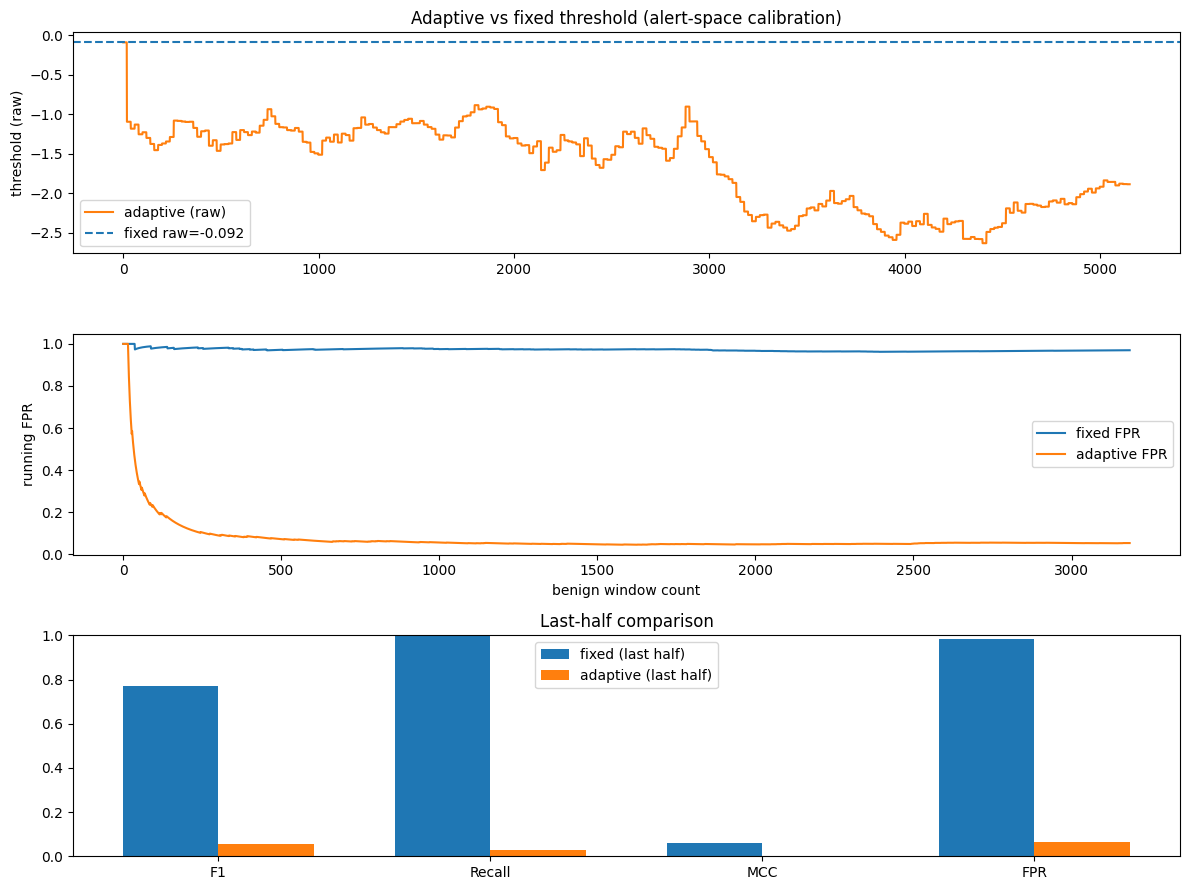

In [7]:
sim = ev.AdaptiveThresholdSimulator(
    alpha=ADAPTIVE_ALPHA,
    buffer_size=BENIGN_BUFFER_SIZE,
    update_every=THRESHOLD_UPDATE_EVERY,
    invert=SCORE_INVERT,
    initial_threshold_raw=thr_fixed,
)
stream_eval = ev.evaluate_stream_strategies(
    y_stream, s_stream, thr_fixed, SCORE_INVERT, sim, half_idx=mid,
)
thr_trace = stream_eval['threshold_trace_raw']

adaptive_report = ev.report_to_jsonable({
    'score_invert': SCORE_INVERT,
    'alert_space': True,
    'stream_ordering': stream_meta,
    'alpha': ADAPTIVE_ALPHA,
    'buffer_size': BENIGN_BUFFER_SIZE,
    'update_every': THRESHOLD_UPDATE_EVERY,
    'fixed_global': stream_eval['fixed_global'],
    'adaptive_global': stream_eval['adaptive_global'],
    'fixed_first_half': stream_eval['fixed_first_half'],
    'fixed_last_half': stream_eval['fixed_last_half'],
    'adaptive_first_half': stream_eval['adaptive_first_half'],
    'adaptive_last_half': stream_eval['adaptive_last_half'],
    'fpr_reduction_last_half': stream_eval['fpr_reduction_last_half'],
    'f1_gain_last_half': stream_eval['f1_gain_last_half'],
    'recall_delta_last_half': stream_eval['recall_delta_last_half'],
})
for target_fpr in (0.05, 0.10, 0.25):
    adaptive_report[f'matched_recall_at_fpr_{int(target_fpr*100)}'] = ev.matched_recall_at_fpr(
        y_stream, s_stream, thr_fixed, SCORE_INVERT, target_fpr,
    )

if RUN_ALPHA_SWEEP:
    alpha_sweep = ev.sweep_adaptive_alpha(
        y_stream, s_stream, thr_fixed, SCORE_INVERT,
        alphas=ALPHA_SWEEP_VALUES,
        buffer_size=BENIGN_BUFFER_SIZE,
        update_every=THRESHOLD_UPDATE_EVERY,
        half_idx=mid,
    )
    adaptive_report['alpha_sweep'] = alpha_sweep
    adaptive_report['best_alpha_by_f1_last_half'] = max(
        alpha_sweep, key=lambda r: r['f1_last_half'])['alpha']
    print('Alpha sweep (last half F1):')
    for row in alpha_sweep:
        print(f"  a={row['alpha']:.1f}  F1={row['f1_last_half']:.4f}  "
              f"FPR={row['fpr_last_half']:.4f}  recall={row['recall_last_half']:.4f}")

print(json.dumps(adaptive_report, indent=2, default=str))
(OUT_DIR / 'adaptive_report.json').write_text(json.dumps(ev.to_jsonable(adaptive_report), indent=2))

benign_mask = y_stream == 0
benign_fixed_fp = ev.predict_alerts(s_stream[benign_mask], thr_fixed, SCORE_INVERT)
benign_adapt_fp = np.array([
    int(ev.to_alert_score(np.array([s_stream[t]]), SCORE_INVERT)[0]
        >= stream_eval['threshold_trace_alert'][t])
    for t in np.where(benign_mask)[0]
], dtype=np.float32)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 1, figsize=(12, 9))

axes[0].plot(thr_trace, color='C1', label='adaptive (raw)')
axes[0].axhline(thr_fixed, color='C0', ls='--', label=f'fixed raw={thr_fixed:.3f}')
axes[0].set_ylabel('threshold (raw)'); axes[0].legend()
axes[0].set_title('Adaptive vs fixed threshold (alert-space calibration)')

axes[1].plot(np.cumsum(benign_fixed_fp) / np.arange(1, len(benign_fixed_fp) + 1), label='fixed FPR')
axes[1].plot(np.cumsum(benign_adapt_fp) / np.arange(1, len(benign_adapt_fp) + 1), label='adaptive FPR')
axes[1].set_xlabel('benign window count'); axes[1].set_ylabel('running FPR'); axes[1].legend()

labels_bar = ['F1', 'Recall', 'MCC', 'FPR']
fixed_last = stream_eval['fixed_last_half']
adapt_last = stream_eval['adaptive_last_half']
x = np.arange(len(labels_bar)); w = 0.35
fixed_vals = [fixed_last['f1'], fixed_last['recall'], fixed_last['mcc'], fixed_last['fpr']]
adapt_vals = [adapt_last['f1'], adapt_last['recall'], adapt_last['mcc'], adapt_last['fpr']]
axes[2].bar(x - w/2, fixed_vals, w, label='fixed (last half)')
axes[2].bar(x + w/2, adapt_vals, w, label='adaptive (last half)')
axes[2].set_xticks(x); axes[2].set_xticklabels(labels_bar)
axes[2].set_ylim(0, 1); axes[2].legend(); axes[2].set_title('Last-half comparison')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig07_adaptive_threshold.png', dpi=300)
plt.savefig(OUT_DIR / 'adaptive_threshold.png', dpi=140)
plt.show()

fa_first = stream_eval['adaptive_first_half']['fpr']
fa_last  = stream_eval['adaptive_last_half']['fpr']
ff_first = stream_eval['fixed_first_half']['fpr']
ff_last  = stream_eval['fixed_last_half']['fpr']

## 6. Incremental fine-tune (WBS §2.2)

**Interpretation:** Benign-only MSE fine-tune may degrade drift-slice AUC (catastrophic forgetting). A negative Δ is a valid research finding — report transparently in Discussion, not as a success claim.

Drift slice: (1546, 10, 163)  benign for FT: 200
AUC drift slice BEFORE fine-tune: 0.8508
AUC drift slice AFTER  fine-tune: 0.7902  delta=-0.0605


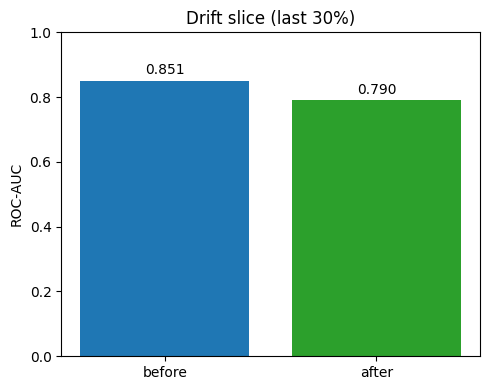

In [8]:
from copy import deepcopy
from torch import optim

def fine_tune_on_recent(m, benign_windows, steps=FINETUNE_STEPS, lr=FINETUNE_LR):
    m = deepcopy(m)
    m.train()
    opt = optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    loader = DataLoader(TensorDataset(torch.from_numpy(benign_windows).float()),
                        batch_size=BATCH_SIZE, shuffle=True)
    for step in range(steps):
        for (xb,) in loader:
            xb = xb.to(device)
            opt.zero_grad(set_to_none=True)
            loss = F.mse_loss(m(xb), xb)
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
            break  # one mini-batch per step
    m.eval()
    return m

X_drift = X_stream[split_idx:]
y_drift = y_stream[split_idx:]
benign_drift_idx = np.where(y_drift == 0)[0]
benign_pick = benign_drift_idx[-FINETUNE_BENIGN_N:] if len(benign_drift_idx) >= FINETUNE_BENIGN_N else benign_drift_idx
X_ft = X_drift[benign_pick]
print(f'Drift slice: {X_drift.shape}  benign for FT: {len(X_ft)}')

s_before = compute_scores(X_drift, model, feat_std)
auc_before = roc_auc_score(y_drift, s_before)
print(f'AUC drift slice BEFORE fine-tune: {auc_before:.4f}')

model_ft = fine_tune_on_recent(model, X_ft, steps=FINETUNE_STEPS, lr=FINETUNE_LR)
s_after = compute_scores(X_drift, model_ft, feat_std)
auc_after = roc_auc_score(y_drift, s_after)
print(f'AUC drift slice AFTER  fine-tune: {auc_after:.4f}  delta={auc_after-auc_before:+.4f}')

finetune_report = {
    'drift_slice_frac': DRIFT_SLICE_FRAC,
    'stream_ordering': stream_meta['ordering_mode'],
    'finetune_benign_n': int(len(X_ft)),
    'finetune_steps': FINETUNE_STEPS,
    'finetune_lr': FINETUNE_LR,
    'auc_before': float(auc_before),
    'auc_after': float(auc_after),
    'auc_delta': float(auc_after - auc_before),
    'interpretation': (
        'negative_delta_expected' if auc_after < auc_before else 'positive_delta'
    ),
    'catastrophic_forgetting_note': (
        'Benign-only MSE fine-tune may collapse attack separation learned offline. '
        'See thesis_drift_aware_notes.md §4.'
    ),
}
(OUT_DIR / 'finetune_report.json').write_text(json.dumps(ev.to_jsonable(finetune_report), indent=2))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['before', 'after'], [auc_before, auc_after], color=['C0', 'C2'])
ax.set_ylim(0, 1); ax.set_ylabel('ROC-AUC'); ax.set_title(f'Drift slice (last {int(DRIFT_SLICE_FRAC*100)}%)')
for i, v in enumerate([auc_before, auc_after]):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_finetune_auc.png', dpi=300)
plt.savefig(OUT_DIR / 'finetune_auc.png', dpi=140)
plt.show()

## 7. Simulated streaming loop (WBS §2.3)

**Terminology:** *Simulated streaming replay* — not live deployment. Order = timestamp (if in npz) else container lexsort. PSI triggers are illustrative.

Logged 5153 steps (container_lexsort order)
  -> /content/vnext_run_local/drift_aware/drift_aware_log.csv


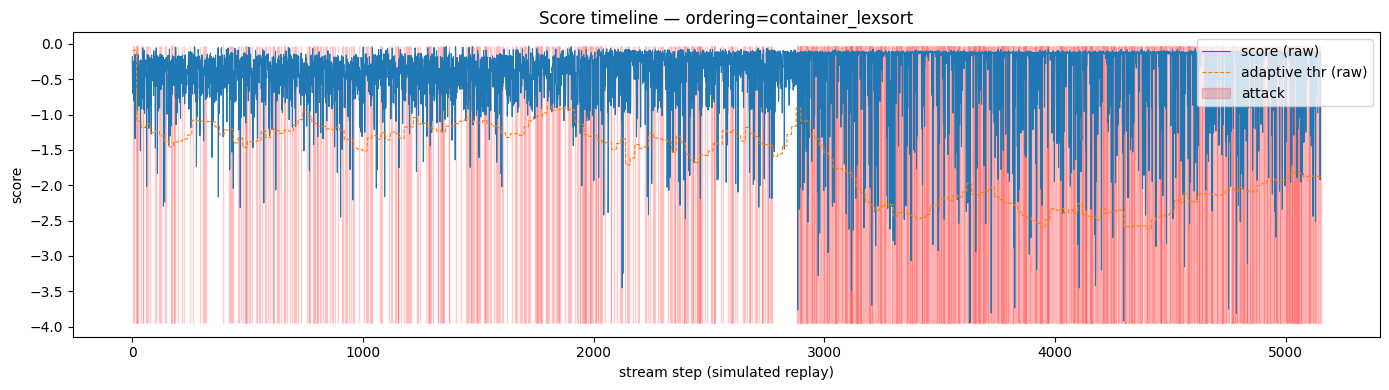

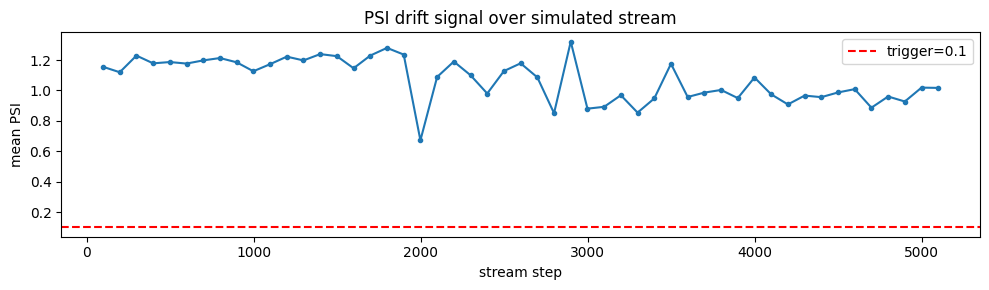

In [9]:
def drift_aware_eval(X_ord, y_ord, s_ord, model_base, drift_baseline=None,
                     model_ft=None, fixed_thr_raw=thr_fixed, invert=SCORE_INVERT):
    """Simulated streaming orchestration: score -> benign buffer -> adaptive thr -> PSI -> optional FT."""
    m = model_base
    ft_done = False
    sim = ev.AdaptiveThresholdSimulator(
        alpha=ADAPTIVE_ALPHA,
        buffer_size=BENIGN_BUFFER_SIZE,
        update_every=THRESHOLD_UPDATE_EVERY,
        invert=invert,
        initial_threshold_raw=fixed_thr_raw,
    )
    logs = []
    for t in range(len(X_ord)):
        xw = X_ord[t:t+1]
        if model_ft is not None and ft_done and t >= split_idx:
            score = float(compute_scores(xw, m, feat_std)[0])
        else:
            score = float(s_ord[t])
        label = int(y_ord[t])
        thr_raw = sim.observe(score, label, t)
        mean_psi = np.nan
        if (t + 1) % PSI_CHECK_EVERY == 0 and drift_baseline is not None:
            w0 = max(0, t + 1 - PSI_CHECK_EVERY)
            psis = psi_on_window_batch(X_ord[w0:t+1], drift_baseline)
            mean_psi = float(np.mean(psis))
            if (not ft_done) and mean_psi > PSI_TRIGGER and model_ft is not None and t >= split_idx:
                m = model_ft
                ft_done = True
        alert = int(ev.to_alert_score(np.array([score]), invert)[0]
                    >= ev.alert_threshold_from_raw(thr_raw, invert))
        logs.append({
            't': t,
            'score': score,
            'threshold_raw': thr_raw,
            'threshold_alert': ev.alert_threshold_from_raw(thr_raw, invert),
            'alert': alert,
            'label': label,
            'mean_psi': mean_psi,
            'finetuned': int(ft_done),
            'stream_ordering': stream_meta['ordering_mode'],
        })
    return logs

logs = drift_aware_eval(X_stream, y_stream, s_stream, model, drift_z, model_ft)

import pandas as pd
df_log = pd.DataFrame(logs)
df_log.to_csv(OUT_DIR / 'drift_aware_log.csv', index=False)
(OUT_DIR / 'drift_aware_log.json').write_text(df_log.to_json(orient='records', indent=2))
print(f'Logged {len(df_log)} steps ({stream_meta["ordering_mode"]} order)')
print(f'  -> {OUT_DIR / "drift_aware_log.csv"}')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_log['score'].values, lw=0.8, label='score (raw)')
ax.plot(df_log['threshold_raw'].values, lw=0.8, ls='--', label='adaptive thr (raw)')
atk = df_log['label'].values == 1
ax.fill_between(np.arange(len(df_log)), df_log['score'].min(), df_log['score'].max(),
                where=atk, alpha=0.2, color='red', label='attack')
ax.set_xlabel('stream step (simulated replay)'); ax.set_ylabel('score'); ax.legend(loc='upper right')
ax.set_title(f'Score timeline — ordering={stream_meta["ordering_mode"]}')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig06_score_timeline.png', dpi=300)
plt.savefig(OUT_DIR / 'score_timeline.png', dpi=140)
plt.show()

psi_rows = df_log[df_log['mean_psi'].notna()]
if len(psi_rows):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(psi_rows['t'], psi_rows['mean_psi'], marker='o', ms=3)
    ax.axhline(PSI_TRIGGER, color='r', ls='--', label=f'trigger={PSI_TRIGGER}')
    ax.set_xlabel('stream step'); ax.set_ylabel('mean PSI'); ax.legend()
    ax.set_title('PSI drift signal over simulated stream')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig08_psi_timeline.png', dpi=300)
    plt.savefig(OUT_DIR / 'psi_timeline.png', dpi=140)
    plt.show()

## 8. Isolation Forest baseline (WBS §3.1)

Benign-only training, mean+max temporal pooling, `contamination='auto'`, validation score-direction calibration. Matches AE training paradigm.

In [10]:
if_baseline = ev.IsolationForestBaseline(
    n_estimators=200,
    contamination='auto',
    random_state=SEED,
    pool_mode='mean_max',
)
print(f'Fitting IsolationForest (benign-only, pool=mean_max) on {X_train.shape[0]} windows ...')
if_baseline.fit(X_train)  # X_train is benign-only in windows_vnext.npz
if_result = if_baseline.evaluate(X_val, y_val, X_test, y_test)
r_if = if_result['metrics']
thr_if = if_result['threshold']

print(f'IsolationForest fit: n={if_result["fit_n_samples"]}  time={if_result["fit_time_s"]:.1f}s')
print(f'  val ROC={if_result["val_roc_auc"]:.4f}  test ROC={if_result["test_roc_auc"]:.4f}')
print(f'  score_inverted={if_result["score_inverted"]}')
print(json.dumps({k: round(v, 4) if isinstance(v, float) else v for k, v in r_if.items()}, indent=2))

# Sensitivity: flattened benign-only (thesis footnote if still weak)
if_flat = ev.IsolationForestBaseline(pool_mode='flatten', contamination='auto', random_state=SEED)
if_flat.fit(X_train)
if_flat_result = if_flat.evaluate(X_val, y_val, X_test, y_test)

baseline_table = {
    'vNext_default': metrics['test_default']['f1_optimal'],
    'vNext_hpo': metrics.get('test_hpo', {}),
    'isolation_forest_mean_max': {
        'metrics': r_if,
        'meta': {k: if_result[k] for k in (
            'pool_mode', 'contamination', 'fit_n_samples', 'fit_time_s', 'score_inverted',
        )},
    },
    'isolation_forest_flatten_sensitivity': {
        'metrics': if_flat_result['metrics'],
        'meta': {k: if_flat_result[k] for k in (
            'pool_mode', 'contamination', 'fit_n_samples', 'score_inverted',
        )},
    },
}
(OUT_DIR / 'baseline_comparison.json').write_text(json.dumps(ev.to_jsonable(baseline_table), indent=2))
print('Saved ->', OUT_DIR / 'baseline_comparison.json')

Fitting IsolationForest (benign-only, pool=mean_max) on 16795 windows ...
IsolationForest fit: n=16795  time=0.5s
  val ROC=0.6931  test ROC=0.6741
  score_inverted=False
{
  "roc_auc": 0.6741,
  "pr_auc": 0.4464,
  "f1": 0.7104,
  "precision": 0.6266,
  "recall": 0.8201,
  "mcc": 0.5034,
  "bal_acc": 0.759,
  "fpr": 0.302,
  "fnr": 0.1799,
  "thr_raw": -0.0495,
  "thr_alert": -0.0495
}
Saved -> /content/vnext_run_local/drift_aware/baseline_comparison.json


## 9. Ablation table (WBS §3.2) — from saved runs + this notebook

In [11]:
# Load optional retrain ablations from model notebook §18b
ABLATION_METRICS_PATH = RUN_DIR / 'metrics_ablation_vnext.json'
ablation_retrain = {}
if ABLATION_METRICS_PATH.is_file():
    ablation_retrain = json.loads(ABLATION_METRICS_PATH.read_text())
    print(f'Loaded retrain ablations: {list(ablation_retrain.keys())}')
else:
    print(f'No retrain ablations at {ABLATION_METRICS_PATH} — run mdc_model_vNext.ipynb §18b')

fixed_stream = ev.classification_metrics(y_stream, s_stream, thr_fixed, SCORE_INVERT)
adapt_last = stream_eval['adaptive_last_half']

abl = [
    {'config': 'Full vNext HPO', 'roc_auc': metrics.get('test_hpo', {}).get('roc_auc', 0.8138),
     'mcc': metrics.get('test_hpo', {}).get('mcc', 0.626),
     'f1': metrics.get('test_hpo', {}).get('f1', 0.774), 'source': 'metrics_vnext.json'},
    {'config': 'vNext default (AUC-best)', 'roc_auc': metrics['test_default']['f1_optimal']['roc_auc'],
     'mcc': metrics['test_default']['f1_optimal']['mcc'],
     'f1': metrics['test_default']['f1_optimal']['f1'], 'source': 'metrics_vnext.json'},
    {'config': 'Multi-seed mean', 'roc_auc': metrics['multi_seed']['roc_auc']['mean'],
     'mcc': metrics['multi_seed']['mcc']['mean'], 'source': 'metrics_vnext.json'},
    {'config': 'Fixed threshold (stream)', 'roc_auc': fixed_stream['roc_auc'],
     'f1': fixed_stream['f1'], 'recall': fixed_stream['recall'],
     'fpr_last_half': stream_eval['fixed_last_half']['fpr'], 'source': '§5 stream'},
    {'config': 'Adaptive threshold (stream)', 'f1_last_half': adapt_last['f1'],
     'recall_last_half': adapt_last['recall'], 'fpr_last_half': adapt_last['fpr'],
     'f1_gain_last_half': stream_eval['f1_gain_last_half'], 'source': '§5 adaptive'},
    {'config': 'Fine-tune on drift slice', 'auc_before': auc_before, 'auc_after': auc_after,
     'auc_delta': auc_after - auc_before, 'source': '§6 fine-tune'},
    {'config': 'Isolation Forest (mean+max)', 'roc_auc': r_if['roc_auc'],
     'mcc': r_if['mcc'], 'f1': r_if['f1'], 'source': '§8'},
]
for name, payload in ablation_retrain.items():
    abl.append({
        'config': f'Retrain ablation: {name}',
        'roc_auc': payload.get('test', {}).get('roc_auc'),
        'mcc': payload.get('test', {}).get('mcc'),
        'f1': payload.get('test', {}).get('f1'),
        'source': 'mdc_model_vNext §18b',
    })

abl_df = pd.DataFrame(abl)
print(abl_df.to_string(index=False))
abl_df.to_csv(OUT_DIR / 'ablation_table.csv', index=False)
print('Saved ->', OUT_DIR / 'ablation_table.csv')

No retrain ablations at /content/vnext_run_local/metrics_ablation_vnext.json — run mdc_model_vNext.ipynb §18b
                     config  roc_auc      mcc       f1             source   recall  fpr_last_half  f1_last_half  recall_last_half  f1_gain_last_half  auc_before  auc_after  auc_delta
             Full vNext HPO 0.813821 0.626046 0.773626 metrics_vnext.json      NaN            NaN           NaN               NaN                NaN         NaN        NaN        NaN
   vNext default (AUC-best) 0.740188 0.588362 0.741204 metrics_vnext.json      NaN            NaN           NaN               NaN                NaN         NaN        NaN        NaN
            Multi-seed mean 0.752857 0.577071      NaN metrics_vnext.json      NaN            NaN           NaN               NaN                NaN         NaN        NaN        NaN
   Fixed threshold (stream) 0.740188      NaN 0.556380          §5 stream 0.990346       0.983488           NaN               NaN                NaN         N

## 10. Bootstrap CI + TPR@FPR + latency (WBS §3.3)

In [12]:
def bootstrap_ci(y, s, metric_fn, n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y[idx])) < 2: continue
        vals.append(metric_fn(y[idx], s[idx]))
    vals = np.array(vals)
    return float(np.mean(vals)), float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

roc_m, roc_lo, roc_hi = bootstrap_ci(y_test, s_test, roc_auc_score)
mcc_m, mcc_lo, mcc_hi = bootstrap_ci(y_test, s_test,
    lambda y, s: matthews_corrcoef(y, ev.predict_alerts(s, thr_fixed, SCORE_INVERT)))
print(f'ROC-AUC bootstrap 95% CI: {roc_m:.4f} [{roc_lo:.4f}, {roc_hi:.4f}]')
print(f'MCC bootstrap 95% CI:     {mcc_m:.4f} [{mcc_lo:.4f}, {mcc_hi:.4f}]')

fpr, tpr, _ = roc_curve(y_test, s_test)
for target in [0.05, 0.10, 0.25]:
    i = np.searchsorted(fpr, target)
    i = min(i, len(tpr)-1)
    print(f'TPR @ FPR={int(target*100):>2}% : {tpr[i]:.4f}')

# Latency benchmark (CPU)
model_cpu = model.to('cpu')
xw = torch.from_numpy(X_test[:1]).float()
for _ in range(10): _ = model_cpu(xw)
times = []
for _ in range(200):
    t0 = time.perf_counter()
    with torch.no_grad(): _ = model_cpu(xw)
    times.append((time.perf_counter() - t0) * 1000)
lat_ms = float(np.median(times))
print(f'Inference latency (CPU, 1 window): {lat_ms:.2f} ms  target<100ms')
model.to(device)

stats_report = {
    'bootstrap_roc_auc': {'mean': roc_m, 'ci_lo': roc_lo, 'ci_hi': roc_hi},
    'bootstrap_mcc': {'mean': mcc_m, 'ci_lo': mcc_lo, 'ci_hi': mcc_hi},
    'latency_ms_cpu_median': lat_ms,
}
(OUT_DIR / 'stats_report.json').write_text(json.dumps(ev.to_jsonable(stats_report), indent=2))

ROC-AUC bootstrap 95% CI: 0.7404 [0.7247, 0.7566]
MCC bootstrap 95% CI:     0.0667 [0.0455, 0.0884]
TPR @ FPR= 5% : 0.0422
TPR @ FPR=10% : 0.5279
TPR @ FPR=25% : 0.7378
Inference latency (CPU, 1 window): 3.36 ms  target<100ms


302

## 11. Thesis figure package — copy from RUN_DIR + new plots

Copied eval_vnext.png
Copied eval_per_attack_type.png
Copied eval_per_attack_roc.png


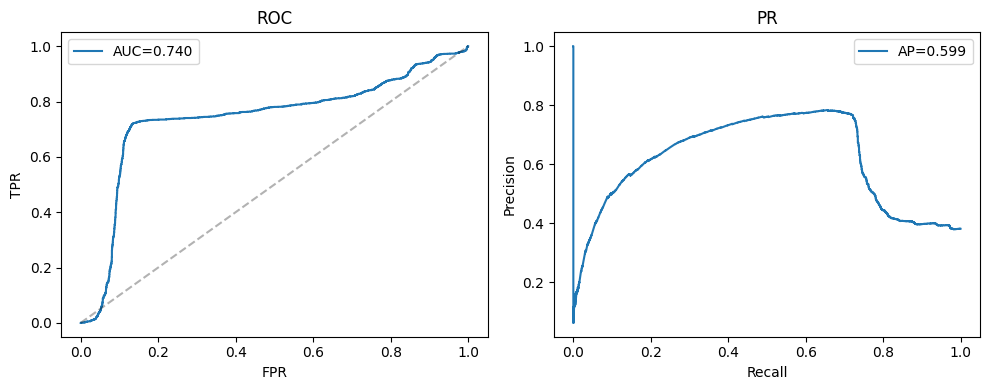


=== DONE ===
Outputs: /content/vnext_run_local/drift_aware
Thesis figures (300 dpi): /content/vnext_run_local/drift_aware/thesis_figures_300dpi
  eval_per_attack_roc_from_run.png
  eval_per_attack_type_from_run.png
  eval_vnext_from_run.png
  fig05_roc_pr.png
  fig06_score_timeline.png
  fig07_adaptive_threshold.png
  fig08_psi_timeline.png
  fig10_finetune_auc.png


In [13]:
COPY_FROM_RUN = [
    'eval_vnext.png', 'eval_per_attack_type.png', 'eval_per_attack_roc.png',
]
for name in COPY_FROM_RUN:
    src = RUN_DIR / name
    if src.is_file():
        shutil.copy2(src, FIG_DIR / name.replace('.png', '_from_run.png'))
        print(f'Copied {name}')

# ROC + PR from saved scores @ 300 dpi
from sklearn.metrics import precision_recall_curve, auc as sk_auc
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test, s_test):.3f}')
ax[0].plot([0,1],[0,1],'k--',alpha=0.3); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR')
ax[0].set_title('ROC'); ax[0].legend()
prec, rec, _ = precision_recall_curve(y_test, s_test)
ax[1].plot(rec, prec, label=f'AP={average_precision_score(y_test, s_test):.3f}')
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision'); ax[1].set_title('PR'); ax[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05_roc_pr.png', dpi=300)
plt.show()

summary = {
    'created_at': datetime.now(timezone.utc).isoformat(),
    'version': 'drift_aware_v2',
    'stream_ordering': stream_meta,
    'adaptive': adaptive_report,
    'finetune': finetune_report,
    'baseline': baseline_table,
    'stats': stats_report,
    'figures_dir': str(FIG_DIR),
    'headline_metrics': {
        'default_test_roc': metrics['test_default']['f1_optimal']['roc_auc'],
        'multi_seed_roc_mean': metrics['multi_seed']['roc_auc']['mean'],
        'hpo_test_roc': metrics.get('test_hpo', {}).get('roc_auc'),
    },
}
summary_json = ev.to_jsonable(summary)
(OUT_DIR / 'drift_aware_summary.json').write_text(json.dumps(summary_json, indent=2))
print('\n=== DONE ===')
print(f'Outputs: {OUT_DIR}')
print(f'Thesis figures (300 dpi): {FIG_DIR}')
for f in sorted(FIG_DIR.glob('*')):
    print(f'  {f.name}')

## 12. Optional — copy outputs to Drive (gentle, no force_remount)
Run if you want `drift_aware/` visible on drive.google.com.

In [14]:
if _IN_COLAB and DRIVE_OUT_DIR.parent.is_dir():
    DRIVE_OUT_DIR.mkdir(parents=True, exist_ok=True)
    for f in OUT_DIR.rglob('*'):
        if f.is_file():
            rel = f.relative_to(OUT_DIR)
            dst = DRIVE_OUT_DIR / rel
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(f, dst)
    print(f'Copied outputs -> {DRIVE_OUT_DIR}')
    print('Refresh drive.google.com -> Module4_MDC/runs/vnext_run/drift_aware/')
else:
    print(f'Local outputs: {OUT_DIR}')

Copied outputs -> /content/drive/MyDrive/Module4_MDC/runs/vnext_run/drift_aware
Refresh drive.google.com -> Module4_MDC/runs/vnext_run/drift_aware/
